In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    brier_score_loss
)

from sklearn.calibration import calibration_curve

from scipy.optimize import (
    milp,
    LinearConstraint,
    Bounds
)

import joblib



df = pd.read_csv("StudentPerformanceFactors.csv")

print("Shape:", df.shape)

Shape: (6607, 20)


In [25]:
display(df.head())

print("\nColumns:")
print(df.columns.tolist())

missing_values = df.isnull().sum()

print("\nMissing values:")
print(missing_values[missing_values > 0])

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nExam score summary:")
print(df["Exam_Score"].describe())

print("\nAttendance summary:")
print(df["Attendance"].describe())

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70



Columns:
['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']

Missing values:
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64

Duplicate rows:
0

Exam score summary:
count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64

Attendance summary:
count    6607.000000
mean       79.977448
std        11.547475
min        60.000000
25%        70.000000
50%        80.000000
75%        90.000000
max       100.000000
Name: Attendance, dtype: float64


In [27]:
# Investigate invalid exam scores above the expected maximum of 100.
invalid_exam_scores = df[df["Exam_Score"] > 100]
print("Rows with Exam_Score > 100:", len(invalid_exam_scores))
display(invalid_exam_scores)

Rows with Exam_Score > 100: 1


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101


In [29]:
df_clean = df[df["Exam_Score"] <= 100].copy()
print("Cleaned shape:", df_clean.shape)
print("Maximum Exam_Score:", df_clean["Exam_Score"].max())

Cleaned shape: (6606, 20)
Maximum Exam_Score: 100


In [31]:
# Separate fixed attendance risk rule required by the project.
df_clean["Attendance_Risk"] = df_clean["Attendance"] < 70

print("Attendance-risk counts:")
print(df_clean["Attendance_Risk"].value_counts())
print("\nAttendance-risk percentages:")
print((df_clean["Attendance_Risk"].value_counts(normalize=True) * 100).round(2))
print("\nMean Exam_Score by Attendance_Risk:")
print(df_clean.groupby("Attendance_Risk")["Exam_Score"].mean())
print("\nAttendance / Exam_Score correlation:")
print(df_clean[["Attendance", "Exam_Score"]].corr())

Attendance-risk counts:
Attendance_Risk
False    5033
True     1573
Name: count, dtype: int64

Attendance-risk percentages:
Attendance_Risk
False    76.19
True     23.81
Name: proportion, dtype: float64

Mean Exam_Score by Attendance_Risk:
Attendance_Risk
False    68.175243
True     64.207883
Name: Exam_Score, dtype: float64

Attendance / Exam_Score correlation:
            Attendance  Exam_Score
Attendance    1.000000    0.582458
Exam_Score    0.582458    1.000000


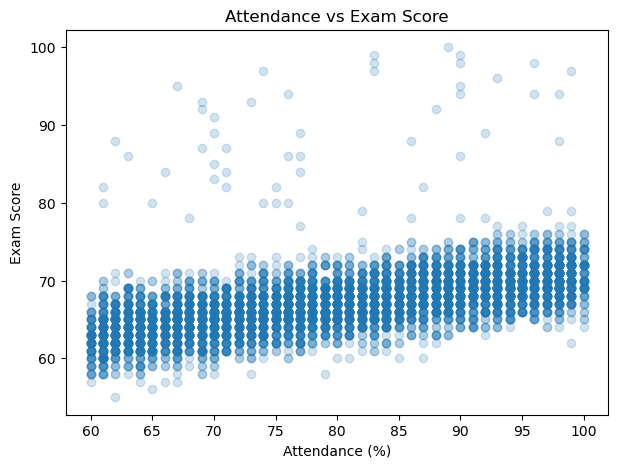

In [33]:
plt.figure(figsize=(7, 5))
plt.scatter(df_clean["Attendance"], df_clean["Exam_Score"], alpha=0.20)
plt.xlabel("Attendance (%)")
plt.ylabel("Exam Score")
plt.title("Attendance vs Exam Score")
plt.show()

In [35]:
numerical_features = [
    "Hours_Studied", "Attendance", "Sleep_Hours",
    "Previous_Scores", "Tutoring_Sessions",
    "Physical_Activity", "Exam_Score"
]

correlations = (
    df_clean[numerical_features]
    .corr()["Exam_Score"]
    .sort_values(ascending=False)
)
print(correlations)

Exam_Score           1.000000
Attendance           0.582458
Hours_Studied        0.446514
Previous_Scores      0.174461
Tutoring_Sessions    0.153754
Physical_Activity    0.027943
Sleep_Hours         -0.016194
Name: Exam_Score, dtype: float64


In [37]:
for column in ["Motivation_Level", "Access_to_Resources", "Parental_Involvement"]:
    print(f"\nMean Exam_Score by {column}:")
    print(df_clean.groupby(column)["Exam_Score"].mean().sort_values(ascending=False))


Mean Exam_Score by Motivation_Level:
Motivation_Level
High      67.704321
Medium    67.330648
Low       66.734504
Name: Exam_Score, dtype: float64

Mean Exam_Score by Access_to_Resources:
Access_to_Resources
High      68.092152
Medium    67.124171
Low       66.203351
Name: Exam_Score, dtype: float64

Mean Exam_Score by Parental_Involvement:
Parental_Involvement
High      68.092767
Medium    67.098156
Low       66.332335
Name: Exam_Score, dtype: float64


In [39]:
threshold_rows = []
for threshold in [60, 62, 63, 64, 65, 66, 67, 68, 69, 70]:
    count = (df_clean["Exam_Score"] < threshold).sum()
    percentage = count / len(df_clean) * 100
    threshold_rows.append({
        "Threshold": threshold,
        "At_Risk_Count": count,
        "At_Risk_Percent": round(percentage, 2)
    })

threshold_table = pd.DataFrame(threshold_rows)
display(threshold_table)

,Threshold,At_Risk_Count,At_Risk_Percent
0,60,68,1.03
1,62,316,4.78
2,63,580,8.78
3,64,951,14.40
4,65,1452,21.98
5,66,2131,32.26
6,67,2882,43.63
7,68,3599,54.48
8,69,4358,65.97
9,70,4982,75.42


In [41]:
ACADEMIC_RISK_THRESHOLD = 65

df_clean["Academic_Risk"] = (
    df_clean["Exam_Score"] < ACADEMIC_RISK_THRESHOLD
).astype(int)

print(df_clean["Academic_Risk"].value_counts())
print((df_clean["Academic_Risk"].value_counts(normalize=True) * 100).round(2))

print("\nAttendance Risk vs Academic Risk:")
display(pd.crosstab(
    df_clean["Attendance_Risk"],
    df_clean["Academic_Risk"],
    margins=True
))

Academic_Risk
0    5154
1    1452
Name: count, dtype: int64
Academic_Risk
0    78.02
1    21.98
Name: proportion, dtype: float64

Attendance Risk vs Academic Risk:


Academic_Risk,0,1,All
Attendance_Risk,,,
False,4464,569,5033
True,690,883,1573
All,5154,1452,6606


In [43]:
# Exam_Score is excluded because Academic_Risk is derived directly from it.
# Attendance_Risk is excluded so the fixed 70% rule remains a separate output.
y = df_clean["Academic_Risk"]
X = df_clean.drop(columns=[
    "Exam_Score",
    "Academic_Risk",
    "Attendance_Risk"
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("\nTraining class proportions:")
print(y_train.value_counts(normalize=True).sort_index())
print("\nTesting class proportions:")
print(y_test.value_counts(normalize=True).sort_index())

X_train: (5284, 19)
X_test: (1322, 19)

Training class proportions:
Academic_Risk
0    0.78028
1    0.21972
Name: proportion, dtype: float64

Testing class proportions:
Academic_Risk
0    0.779879
1    0.220121
Name: proportion, dtype: float64


In [45]:
numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:", numerical_columns)
print("Categorical columns:", categorical_columns)

Numerical columns: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']
Categorical columns: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


In [47]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numerical", numerical_pipeline, numerical_columns),
    ("categorical", categorical_pipeline, categorical_columns)
])

In [49]:
model_estimators = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_rows = []
for model_name, estimator in model_estimators.items():
    pipeline = Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("model", clone(estimator))
    ])

    scores = cross_validate(
        pipeline, X_train, y_train,
        cv=cv, scoring=scoring, n_jobs=-1
    )

    cv_rows.append({
        "Model": model_name,
        "CV_Accuracy_Mean": scores["test_accuracy"].mean(),
        "CV_Precision_Mean": scores["test_precision"].mean(),
        "CV_Recall_Mean": scores["test_recall"].mean(),
        "CV_F1_Mean": scores["test_f1"].mean(),
        "CV_ROC_AUC_Mean": scores["test_roc_auc"].mean(),
        "CV_Recall_Std": scores["test_recall"].std()
    })

cv_results_df = (
    pd.DataFrame(cv_rows)
    .sort_values(["CV_Recall_Mean", "CV_F1_Mean", "CV_ROC_AUC_Mean"], ascending=False)
    .reset_index(drop=True)
)

display(cv_results_df.round(4))

,Model,CV_Accuracy_Mean,CV_Precision_Mean,CV_Recall_Mean,CV_F1_Mean,CV_ROC_AUC_Mean,CV_Recall_Std
0,Logistic Regression,0.9828,0.9769,0.9440,0.9601,0.9971,0.0076
1,SVM,0.9703,0.9597,0.9027,0.9302,0.9950,0.0181
2,Decision Tree,0.8653,0.6890,0.7063,0.6973,0.8082,0.0091
3,Random Forest,0.9023,0.9423,0.5917,0.7267,0.9753,0.0283


In [51]:
SELECTED_MODEL_NAME = "Logistic Regression"
selected_model = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", clone(model_estimators[SELECTED_MODEL_NAME]))
])

selected_model.fit(X_train, y_train)
print("Selected model:", SELECTED_MODEL_NAME)

Selected model: Logistic Regression


In [55]:
test_predictions = selected_model.predict(X_test)
test_probabilities = selected_model.predict_proba(X_test)[:, 1]

heldout_metrics = pd.DataFrame([{
    "Model": SELECTED_MODEL_NAME,
    "Accuracy": accuracy_score(y_test, test_predictions),
    "Precision": precision_score(y_test, test_predictions, zero_division=0),
    "Recall": recall_score(y_test, test_predictions, zero_division=0),
    "F1": f1_score(y_test, test_predictions, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, test_probabilities),
    "Brier_Score": brier_score_loss(y_test, test_probabilities)
}])

display(heldout_metrics.round(4))
print("\nClassification report:")
print(classification_report(
    y_test, test_predictions,
    target_names=["Not At Risk", "At Risk"]
))

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Brier_Score
0,Logistic Regression,0.9834,0.9753,0.9485,0.9617,0.9981,0.0162



Classification report:
              precision    recall  f1-score   support

 Not At Risk       0.99      0.99      0.99      1031
     At Risk       0.98      0.95      0.96       291

    accuracy                           0.98      1322
   macro avg       0.98      0.97      0.98      1322
weighted avg       0.98      0.98      0.98      1322



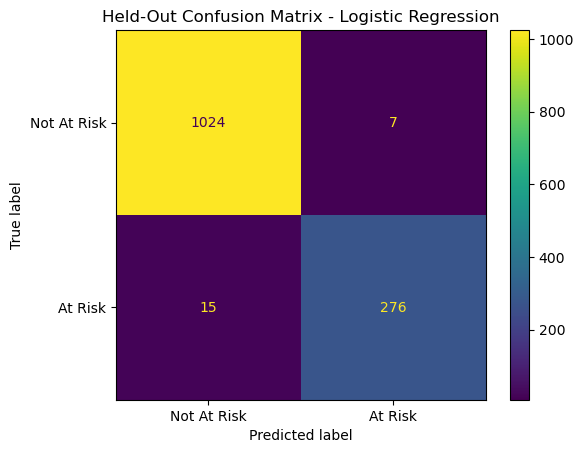

In [57]:
cm = confusion_matrix(y_test, test_predictions)
display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not At Risk", "At Risk"]
)
display_cm.plot()
plt.title("Held-Out Confusion Matrix - Logistic Regression")
plt.show()

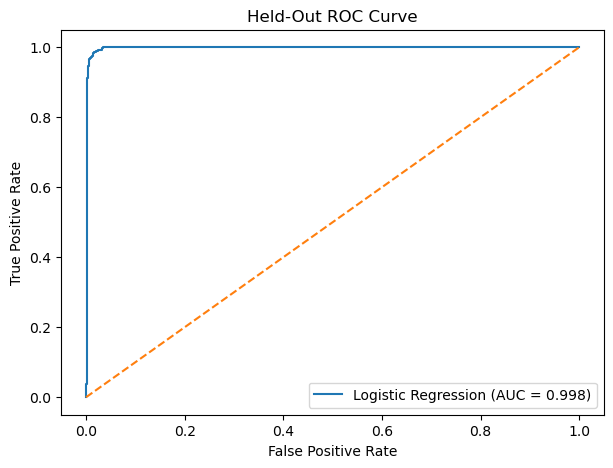

In [59]:
fpr, tpr, _ = roc_curve(y_test, test_probabilities)
auc_score = roc_auc_score(y_test, test_probabilities)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Held-Out ROC Curve")
plt.legend()
plt.show()

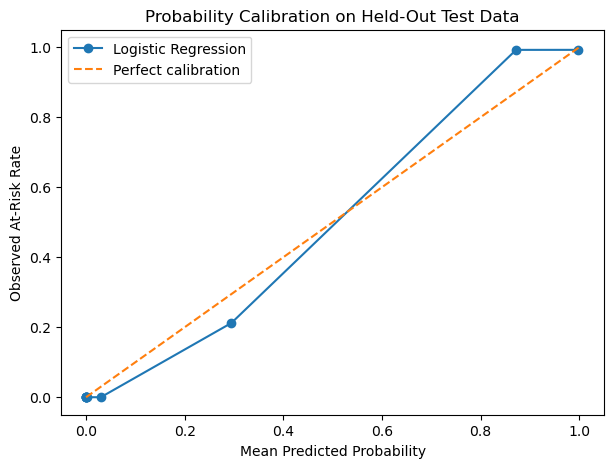

Brier score (lower is better): 0.0162


In [61]:
prob_true, prob_pred = calibration_curve(
    y_test, test_probabilities, n_bins=10, strategy="quantile"
)

plt.figure(figsize=(7, 5))
plt.plot(prob_pred, prob_true, marker="o", label="Logistic Regression")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed At-Risk Rate")
plt.title("Probability Calibration on Held-Out Test Data")
plt.legend()
plt.show()

print("Brier score (lower is better):", round(brier_score_loss(y_test, test_probabilities), 4))

In [63]:
# This sensitivity analysis uses training set rows only, so the held out test set remains untouched.
sensitivity_rows = []
train_indices = X_train.index
X_sensitivity = X.loc[train_indices]

for threshold in [64, 65, 66]:
    y_sensitivity = (
        df_clean.loc[train_indices, "Exam_Score"] < threshold
    ).astype(int)

    sensitivity_pipeline = Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ])

    scores = cross_validate(
        sensitivity_pipeline, X_sensitivity, y_sensitivity,
        cv=cv,
        scoring={"recall": "recall", "f1": "f1", "roc_auc": "roc_auc"},
        n_jobs=-1
    )

    sensitivity_rows.append({
        "Threshold": threshold,
        "At_Risk_Percent_Training": y_sensitivity.mean() * 100,
        "CV_Recall_Mean": scores["test_recall"].mean(),
        "CV_F1_Mean": scores["test_f1"].mean(),
        "CV_ROC_AUC_Mean": scores["test_roc_auc"].mean()
    })

target_sensitivity_df = pd.DataFrame(sensitivity_rows)
display(target_sensitivity_df.round(4))

,Threshold,At_Risk_Percent_Training,CV_Recall_Mean,CV_F1_Mean,CV_ROC_AUC_Mean
0,64,14.5344,0.9297,0.9482,0.9979
1,65,21.9720,0.9440,0.9601,0.9971
2,66,32.2294,0.9689,0.9706,0.9960


In [65]:
evaluation_df = df_clean.loc[X_test.index].copy()
evaluation_df["Academic_Risk_Probability"] = test_probabilities

# Descriptive probability bands for user-facing interpretation.
evaluation_df["Risk_Category"] = pd.cut(
    evaluation_df["Academic_Risk_Probability"],
    bins=[-0.001, 0.25, 0.50, 0.75, 1.001],
    labels=["Low", "Medium", "High", "Very High"]
)

evaluation_df["Attendance_Risk_Numeric"] = evaluation_df["Attendance_Risk"].astype(int)
evaluation_df["Previous_Performance_Risk"] = 1 - (evaluation_df["Previous_Scores"] / 100)

BASE_WEIGHTS = {
    "ml_risk": 0.60,
    "attendance_risk": 0.25,
    "previous_performance_risk": 0.15
}

def calculate_utility(data, weights=BASE_WEIGHTS):
    return (
        weights["ml_risk"] * data["Academic_Risk_Probability"]
        + weights["attendance_risk"] * data["Attendance_Risk_Numeric"]
        + weights["previous_performance_risk"] * data["Previous_Performance_Risk"]
    )

evaluation_df["Intervention_Utility"] = calculate_utility(evaluation_df)

# Eligibility is deliberately broader than ML classification alone.
evaluation_df["Eligible_For_Intervention"] = (
    (evaluation_df["Academic_Risk_Probability"] >= 0.50)
    | evaluation_df["Attendance_Risk"]
)

eligible_students = evaluation_df[
    evaluation_df["Eligible_For_Intervention"]
].copy()

INTERVENTION_CAPACITY = 10
capacity = min(INTERVENTION_CAPACITY, len(eligible_students))

print("Held-out students:", len(evaluation_df))
print("Eligible students:", len(eligible_students))
print("Intervention capacity:", capacity)
print("\nRisk categories:")
print(evaluation_df["Risk_Category"].value_counts())

Held-out students: 1322
Eligible students: 419
Intervention capacity: 10

Risk categories:
Risk_Category
Low          984
Very High    243
Medium        55
High          40
Name: count, dtype: int64


In [67]:
# Strategy 1: repeated random allocation baseline (1,000 trials).
RANDOM_TRIALS = 1000
rng = np.random.default_rng(42)

random_trial_rows = []
eligible_index_array = eligible_students.index.to_numpy()

for trial in range(RANDOM_TRIALS):
    chosen_indices = rng.choice(eligible_index_array, size=capacity, replace=False)
    selection = eligible_students.loc[chosen_indices]
    random_trial_rows.append({
        "Trial": trial + 1,
        "Total_Utility": selection["Intervention_Utility"].sum(),
        "Average_ML_Risk": selection["Academic_Risk_Probability"].mean(),
        "Attendance_Risk_Students": selection["Attendance_Risk"].sum(),
        "High_ML_Risk_Students": (selection["Academic_Risk_Probability"] >= 0.50).sum()
    })

random_baseline_df = pd.DataFrame(random_trial_rows)
random_summary = {
    "Mean_Utility": random_baseline_df["Total_Utility"].mean(),
    "Utility_Std": random_baseline_df["Total_Utility"].std(),
    "Utility_2.5pct": random_baseline_df["Total_Utility"].quantile(0.025),
    "Utility_97.5pct": random_baseline_df["Total_Utility"].quantile(0.975)
}
print(random_summary)

{'Mean_Utility': 6.095565011540826, 'Utility_Std': 0.7322386484792376, 'Utility_2.5pct': 4.72446556579431, 'Utility_97.5pct': 7.60991119711897}


In [69]:
# Strategy 2: select the highest ML risk students.
highest_risk_selection = (
    eligible_students
    .sort_values("Academic_Risk_Probability", ascending=False)
    .head(capacity)
)

# Strategy 3: MILP optimisation of total intervention utility.
optimisation_data = (
    eligible_students
    .reset_index()
    .rename(columns={"index": "Student_Index"})
)

utility_values = optimisation_data["Intervention_Utility"].to_numpy()
n_students = len(optimisation_data)

objective = -utility_values  # scipy.milp minimises, so negate utility to maximise it.
integrality = np.ones(n_students)
bounds = Bounds(lb=np.zeros(n_students), ub=np.ones(n_students))
constraint = LinearConstraint(
    np.ones((1, n_students)),
    lb=capacity,
    ub=capacity
)

optimisation_result = milp(
    c=objective,
    integrality=integrality,
    bounds=bounds,
    constraints=constraint
)

if not optimisation_result.success:
    raise RuntimeError(optimisation_result.message)

selected_positions = np.where(optimisation_result.x > 0.5)[0]
optimised_selection = (
    optimisation_data.iloc[selected_positions]
    .copy()
    .sort_values("Intervention_Utility", ascending=False)
)

print("Optimisation successful:", optimisation_result.success)

Optimisation successful: True


In [71]:
def evaluate_fixed_strategy(selection, strategy_name):
    return {
        "Strategy": strategy_name,
        "Students_Selected": len(selection),
        "Total_Utility_Mean": selection["Intervention_Utility"].sum(),
        "Utility_Std": 0.0,
        "Average_ML_Risk": selection["Academic_Risk_Probability"].mean(),
        "Attendance_Risk_Students": selection["Attendance_Risk"].sum(),
        "High_ML_Risk_Students": (selection["Academic_Risk_Probability"] >= 0.50).sum()
    }

strategy_rows = [{
    "Strategy": "Random Allocation (1,000-trial mean)",
    "Students_Selected": capacity,
    "Total_Utility_Mean": random_baseline_df["Total_Utility"].mean(),
    "Utility_Std": random_baseline_df["Total_Utility"].std(),
    "Average_ML_Risk": random_baseline_df["Average_ML_Risk"].mean(),
    "Attendance_Risk_Students": random_baseline_df["Attendance_Risk_Students"].mean(),
    "High_ML_Risk_Students": random_baseline_df["High_ML_Risk_Students"].mean()
}]

strategy_rows.append(evaluate_fixed_strategy(
    highest_risk_selection, "Highest ML Risk Allocation"
))
strategy_rows.append(evaluate_fixed_strategy(
    optimised_selection, "Optimised Utility Allocation"
))

strategy_comparison = pd.DataFrame(strategy_rows)
display(strategy_comparison.round(4))

,Strategy,Students_Selected,Total_Utility_Mean,Utility_Std,Average_ML_Risk,Attendance_Risk_Students,High_ML_Risk_Students
0,"Random Allocation (1,000-trial mean)",10,6.0956,0.7322,0.6412,7.41,6.705
1,Highest ML Risk Allocation,10,8.7555,0.0000,1.0000,9.00,10.000
2,Optimised Utility Allocation,10,9.2268,0.0000,0.9999,10.00,10.000


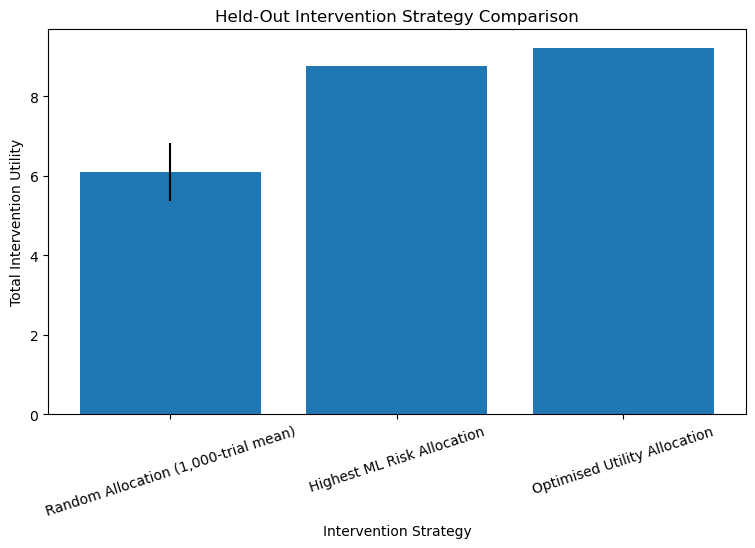

In [73]:
plt.figure(figsize=(9, 5))
plt.bar(
    strategy_comparison["Strategy"],
    strategy_comparison["Total_Utility_Mean"],
    yerr=strategy_comparison["Utility_Std"]
)
plt.xlabel("Intervention Strategy")
plt.ylabel("Total Intervention Utility")
plt.title("Held-Out Intervention Strategy Comparison")
plt.xticks(rotation=18)
plt.show()

In [75]:
# Confirm the equivalence under the current simple unit capacity formulation.
top_utility_indices = set(
    eligible_students.nlargest(capacity, "Intervention_Utility").index
)
optimised_indices = set(optimised_selection["Student_Index"].tolist())

print(
    "MILP selection equals direct top-utility selection:",
    optimised_indices == top_utility_indices
)

MILP selection equals direct top-utility selection: True


In [77]:
weight_schemes = {
    "Base 60/25/15": {
        "ml_risk": 0.60, "attendance_risk": 0.25, "previous_performance_risk": 0.15
    },
    "Risk-heavy 70/20/10": {
        "ml_risk": 0.70, "attendance_risk": 0.20, "previous_performance_risk": 0.10
    },
    "Attendance-heavy 50/35/15": {
        "ml_risk": 0.50, "attendance_risk": 0.35, "previous_performance_risk": 0.15
    },
    "Performance-heavy 50/20/30": {
        "ml_risk": 0.50, "attendance_risk": 0.20, "previous_performance_risk": 0.30
    }
}

base_selected = set(
    eligible_students.nlargest(capacity, "Intervention_Utility").index
)

weight_sensitivity_rows = []
for scheme_name, weights in weight_schemes.items():
    temp = eligible_students.copy()
    temp["Scheme_Utility"] = calculate_utility(temp, weights)
    selected = temp.nlargest(capacity, "Scheme_Utility")
    selected_indices = set(selected.index)

    weight_sensitivity_rows.append({
        "Weight_Scheme": scheme_name,
        "Selected_Overlap_With_Base": len(selected_indices & base_selected),
        "Average_ML_Risk": selected["Academic_Risk_Probability"].mean(),
        "Attendance_Risk_Students": selected["Attendance_Risk"].sum(),
        "Average_Previous_Performance_Risk": selected["Previous_Performance_Risk"].mean()
    })

weight_sensitivity_df = pd.DataFrame(weight_sensitivity_rows)
display(weight_sensitivity_df.round(4))

,Weight_Scheme,Selected_Overlap_With_Base,Average_ML_Risk,Attendance_Risk_Students,Average_Previous_Performance_Risk
0,Base 60/25/15,10,0.9999,10,0.485
1,Risk-heavy 70/20/10,10,0.9999,10,0.485
2,Attendance-heavy 50/35/15,10,0.9999,10,0.485
3,Performance-heavy 50/20/30,10,0.9999,10,0.485


In [83]:
final_model = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])
final_model.fit(X, y)

df_deployment = df_clean.copy()
df_deployment["Academic_Risk_Probability"] = final_model.predict_proba(X)[:, 1]
df_deployment["Risk_Category"] = pd.cut(
    df_deployment["Academic_Risk_Probability"],
    bins=[-0.001, 0.25, 0.50, 0.75, 1.001],
    labels=["Low", "Medium", "High", "Very High"]
)
df_deployment["Attendance_Risk_Numeric"] = df_deployment["Attendance_Risk"].astype(int)
df_deployment["Previous_Performance_Risk"] = 1 - (df_deployment["Previous_Scores"] / 100)
df_deployment["Intervention_Utility"] = calculate_utility(df_deployment, BASE_WEIGHTS)
df_deployment["Eligible_For_Intervention"] = (
    (df_deployment["Academic_Risk_Probability"] >= 0.50)
    | df_deployment["Attendance_Risk"]
)

print("Final deployment model trained on all cleaned rows:", len(df_deployment))
display(df_deployment[[
    "Attendance", "Previous_Scores", "Exam_Score",
    "Attendance_Risk", "Academic_Risk_Probability",
    "Risk_Category", "Intervention_Utility",
    "Eligible_For_Intervention"
]].head(10))

Final deployment model trained on all cleaned rows: 6606


,Attendance,Previous_Scores,Exam_Score,Attendance_Risk,Academic_Risk_Probability,Risk_Category,Intervention_Utility,Eligible_For_Intervention
0,84,73,67,False,4.113773e-04,Low,0.040747,False
1,64,59,61,True,9.999900e-01,Very High,0.911494,True
2,98,91,74,False,5.320300e-14,Low,0.013500,False
3,89,98,71,False,2.153618e-09,Low,0.003000,False
4,92,65,70,False,2.824645e-09,Low,0.052500,False
5,88,89,71,False,3.177807e-10,Low,0.016500,False
6,84,68,67,False,1.555930e-04,Low,0.048093,False
7,78,50,66,False,4.087700e-03,Low,0.077453,False
8,94,80,69,False,7.785748e-07,Low,0.030000,False
9,98,71,72,False,2.309652e-11,Low,0.043500,False


In [87]:
# Save the trained model
joblib.dump(
    final_model,
    "academic_risk_model.pkl"
)
# Save project results
df_deployment.to_csv(
    "student_risk_results.csv",
    index=False
)
cv_results_df.to_csv(
    "model_comparison_cross_validation.csv",
    index=False
)
heldout_metrics.to_csv(
    "logistic_regression_heldout_metrics.csv",
    index=False
)
target_sensitivity_df.to_csv(
    "target_threshold_sensitivity.csv",
    index=False
)
strategy_comparison.to_csv(
    "intervention_strategy_comparison.csv",
    index=False
)
random_baseline_df.to_csv(
    "random_allocation_1000_trials.csv",
    index=False
)
weight_sensitivity_df.to_csv(
    "utility_weight_sensitivity.csv",
    index=False
)
print("Files saved successfully:")

for filename in [
    "academic_risk_model.pkl",
    "student_risk_results.csv",
    "model_comparison_cross_validation.csv",
    "logistic_regression_heldout_metrics.csv",
    "target_threshold_sensitivity.csv",
    "intervention_strategy_comparison.csv",
    "random_allocation_1000_trials.csv",
    "utility_weight_sensitivity.csv"
]:
    print(" -", filename)

Files saved successfully:
 - academic_risk_model.pkl
 - student_risk_results.csv
 - model_comparison_cross_validation.csv
 - logistic_regression_heldout_metrics.csv
 - target_threshold_sensitivity.csv
 - intervention_strategy_comparison.csv
 - random_allocation_1000_trials.csv
 - utility_weight_sensitivity.csv
